### Mini Project: COVID-19 Detection from Chest X-rays using CNN
This project builds a Convolutional Neural Network (CNN) model to automatically detect COVID-19 from chest X-ray images[cite: 1]. The dataset contains three classes: COVID-19, Normal (no disease), and Viral Pneumonia[cite: 1].

In [17]:
# Imports necessary libraries for data processing, visualization, deep learning (TensorFlow/Keras), and hyperparameter tuning.
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt
import kagglehub

### Data Loading and Exploration

Loaded 251 training images and 66 test images.


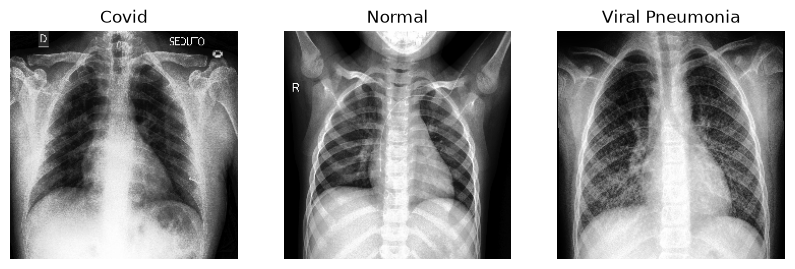

In [18]:
# Loads images from train and test folders, resizes them to 224x224, labels them, and prints dataset sizes.
base_dir = kagglehub.dataset_download('pranavraikokte/covid19-image-dataset') + '/Covid19-dataset'
classes = ['Covid', 'Normal', 'Viral Pneumonia']
img_size = 224

def load_data(folder_name):
    X_data, y_data = [], []
    for category in classes:
        path = os.path.join(base_dir, folder_name, category)
        class_num = classes.index(category)
        for img in os.listdir(path):
            img_array = cv2.imread(os.path.join(path, img))
            if img_array is not None:
                resized_array = cv2.resize(img_array, (img_size, img_size))
                X_data.append(resized_array)
                y_data.append(class_num)
    return np.array(X_data), y_data

X_train_full, y_train_full_list = load_data('train')
X_test, y_test_list = load_data('test')

print(f"Loaded {len(X_train_full)} training images and {len(X_test)} test images.")

# Display a few sample images from each class
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    idx = y_train_full_list.index(i)
    plt.imshow(cv2.cvtColor(X_train_full[idx], cv2.COLOR_BGR2RGB))
    plt.title(classes[i])
    plt.axis('off')
plt.show()

# Convert label lists to numpy arrays for further processing
y_train_full = np.array(y_train_full_list)
y_test = np.array(y_test_list)

### EDA Class Distribution

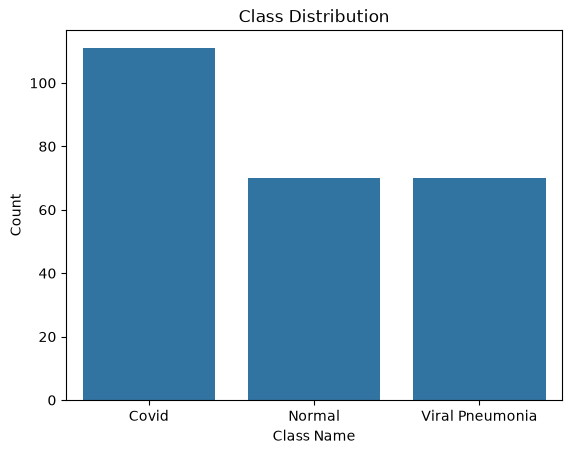

In [19]:
# Visualizes the class distribution using a bar plot to observe patterns in the data.
sns.countplot(x=[classes[label] for label in y_train_full])
plt.title('Class Distribution')
plt.xlabel('Class Name')
plt.ylabel('Count')
plt.show()

### Preprocess and split only validation from train

In [20]:
# Normalizes pixel values, encodes labels, and splits the training data to create a validation set (80-20% split).
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

y_train_full_encoded = to_categorical(y_train_full, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full_encoded, test_size=0.2, random_state=42)

### Handle Class Imbalance

In [21]:
# Analyzes class imbalance and sets up techniques like computing class weights and data augmentation using ImageDataGenerator.
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(class_weights))

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

### Model Evaluation Function

In [22]:
# Defines a reusable function to evaluate models, plot train vs val metrics, print ROC-AUC/Test Acc, and display the confusion matrix.
def evaluate_model(model, history, X_test, y_test):
    # Print Trainable Parameters and Test Accuracy
    print(f"Trainable Parameters: {np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])}")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    
    # Overfitting Checks (Loss and Accuracy Plots)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Overfitting Check: Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Overfitting Check: Accuracy')
    plt.show()
    
    # Generate Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # ROC-AUC Score (Multi-class One-vs-Rest)
    roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
    print(f"ROC-AUC Score (OVR): {roc_auc:.4f}\n")
    
    # Classification Report
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))
    
    # Confusion Matrix Heatmap
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

### Model 1: Basic CNN with Dropout and Augmentation

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 732ms/step - accuracy: 0.4350 - loss: 23.4383 - val_accuracy: 0.4706 - val_loss: 2.6214
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 650ms/step - accuracy: 0.3650 - loss: 6.9474 - val_accuracy: 0.6863 - val_loss: 1.1277
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 714ms/step - accuracy: 0.4800 - loss: 2.0606 - val_accuracy: 0.7843 - val_loss: 0.5559
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 702ms/step - accuracy: 0.5150 - loss: 0.9923 - val_accuracy: 0.8039 - val_loss: 0.6272
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 723ms/step - accuracy: 0.6050 - loss: 0.8481 - val_accuracy: 0.8431 - val_loss: 0.5762
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 660ms/step - accuracy: 0.6250 - loss: 0.7921 - val_accuracy: 0.8627 - val_loss: 0.4798
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 694ms/step - accuracy: 0.6700 - loss: 0.7923 - val_accuracy: 0.8627 - val_loss: 0.4437
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 646ms/step - accuracy: 0.6300 - loss: 0.7791 - val_accuracy: 0.8039 - val_loss

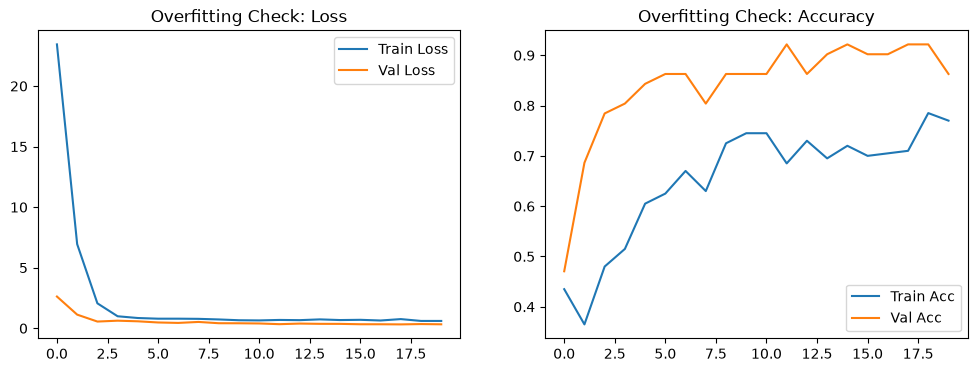

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
ROC-AUC Score (OVR): 0.9387

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      0.81      0.89        26
         Normal       0.84      0.80      0.82        20
Viral Pneumonia       0.69      0.90      0.78        20

       accuracy                           0.83        66
      macro avg       0.84      0.84      0.83        66
   weighted avg       0.86      0.83      0.84        66



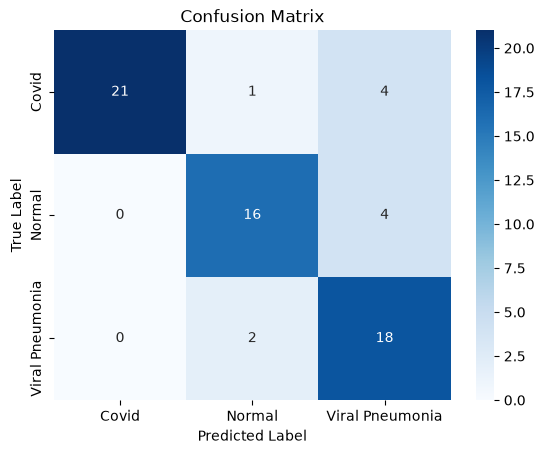

In [ ]:
# Creates and trains a basic CNN with Dropout and Data Augmentation to prevent overfitting.
model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Randomly drops 50% of neurons to prevent memorization
    Dense(3, activation='softmax')
])

model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Replaced X_train, y_train with datagen.flow() to use augmented images
history_1 = model_1.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)
evaluate_model(model_1, history_1, X_test, y_test)

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 841ms/step - accuracy: 0.2950 - loss: 1.7801 - val_accuracy: 0.2745 - val_loss: 1.1350
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 759ms/step - accuracy: 0.3050 - loss: 1.0926 - val_accuracy: 0.2941 - val_loss: 1.0318
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 725ms/step - accuracy: 0.3700 - loss: 0.9988 - val_accuracy: 0.7647 - val_loss: 0.8484
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 742ms/step - accuracy: 0.6550 - loss: 0.8143 - val_accuracy: 0.7255 - val_loss: 0.6212
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 754ms/step - accuracy: 0.6800 - loss: 0.8247 - val_accuracy: 0.7647 - val_loss: 0.6389
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 747ms/step - accuracy: 0.7300 - loss: 0.7456 - val_accuracy: 0.7647 - val_loss: 0.6396
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 736ms/step - accuracy: 0.6800 - loss: 0.7250 - val_accuracy: 0.8039 - val_loss: 0.4537
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 908ms/step - accuracy: 0.7400 - loss: 0.6525 - val_accuracy: 0.8039 - val_loss

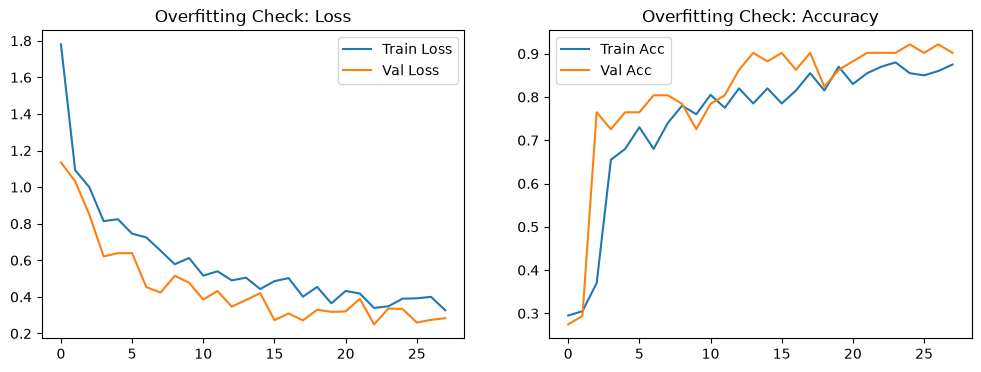

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step
ROC-AUC Score (OVR): 0.9399

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      0.88      0.94        26
         Normal       0.62      1.00      0.77        20
Viral Pneumonia       0.73      0.40      0.52        20

       accuracy                           0.77        66
      macro avg       0.78      0.76      0.74        66
   weighted avg       0.80      0.77      0.76        66



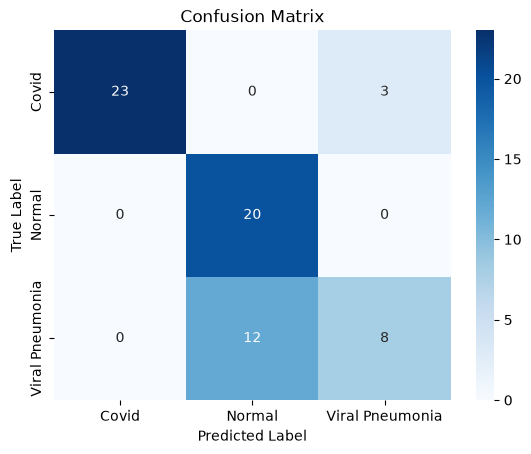

In [43]:
# Deep CNN Architecture: Building a "bigger engine" from scratch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_2 = Sequential([
    # Block 1: The Basic "Eyes" (Finds edges and contrast)
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    
    # Block 2: The Intermediate "Eyes" (Combines edges into shapes/textures)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Block 3: The Advanced "Eyes" (Finds complex medical patterns)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # The Decision Maker
    Flatten(),
    Dense(256, activation='relu'), # Increased brainpower (from 128 to 256)
    Dropout(0.5), # Standard defense against memorization
    Dense(3, activation='softmax')
])

model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# We allow up to 30 epochs because a deeper model built from scratch takes longer to learn.
# EarlyStopping will still automatically stop it if it finishes learning early.
history_2 = model_2.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val), 
    epochs=30, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_2, history_2, X_test, y_test)

### Model 2: Transfer Learning VGG16 with GAP, Dropout, and Reduced Learning Rate

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.3900 - loss: 4.6041 - val_accuracy: 0.3333 - val_loss: 4.4937
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.5350 - loss: 4.2979 - val_accuracy: 0.8235 - val_loss: 4.1346
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.7250 - loss: 4.0305 - val_accuracy: 0.8431 - val_loss: 3.8257
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.7950 - loss: 3.7766 - val_accuracy: 0.8627 - val_loss: 3.6296
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8250 - loss: 3.5958 - val_accuracy: 0.8824 - val_loss: 3.5053
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8650 - loss: 3.4448 - val_accuracy: 0.9412 - val_loss: 3.2896
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8700 - loss: 3.3611 - val_accuracy: 0.9216 - val_loss: 3.1904
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.9000 - loss: 3.2299 - val_accuracy: 0.8627 - val_loss: 3.2285
Epoch 9/

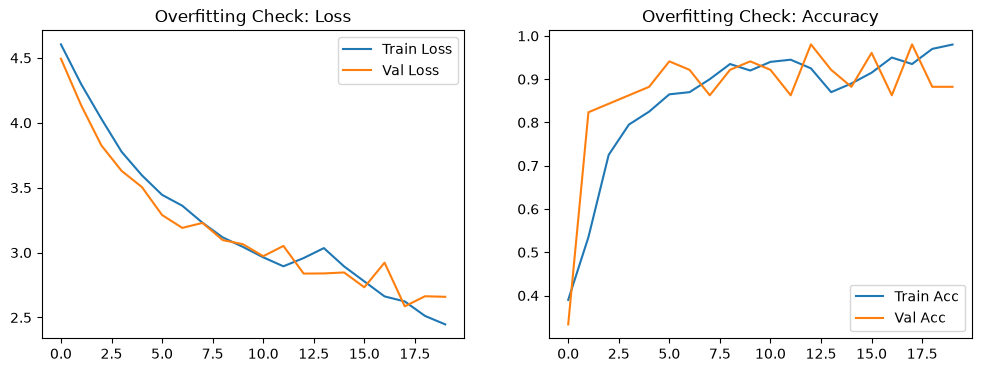

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
ROC-AUC Score (OVR): 0.9971

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       0.91      1.00      0.95        20
Viral Pneumonia       1.00      0.90      0.95        20

       accuracy                           0.97        66
      macro avg       0.97      0.97      0.97        66
   weighted avg       0.97      0.97      0.97        66



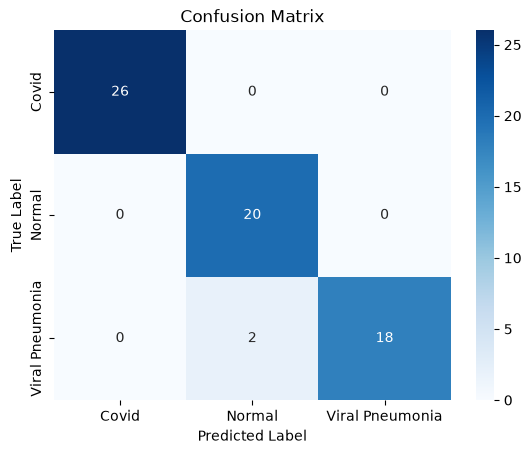

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# 1. Unfreeze the last 4 layers again so it can actually learn X-ray textures
for layer in base_model_vgg.layers[:-4]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_vgg.output)

# 2. Added L2 Regularizer to strictly penalize memorization
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)

# 3. Lowered Dropout to 0.3 so we aren't blinding the model too much
x = Dropout(0.3)(x) 
output = Dense(3, activation='softmax')(x)

model_3 = Model(inputs=base_model_vgg.input, outputs=output)

model_3.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_3 = model_3.fit(
    datagen.flow(X_train, y_train, batch_size=32), 
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_3, history_3, X_test, y_test)

### Transfer Learning + Data Augmentation with ResNet50 Fine-Tuned

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze the ENTIRE base model to keep ResNet's Batch Normalization stable
for layer in base_model_resnet.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_resnet.output)

# Removed the L2 Regularizer - let ResNet breathe
x = Dense(256, activation='relu')(x)

# Standard Dropout is all the protection it needs
x = Dropout(0.5)(x) 
output = Dense(3, activation='softmax')(x)

model_4 = Model(inputs=base_model_resnet.input, outputs=output)

# Use the standard, safe learning rate
model_4.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history_4 = model_4.fit(
    datagen.flow(X_train, y_train, batch_size=32), 
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_4, history_4, X_test, y_test)

Epoch 1/20


### Model Comparison Table

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def get_model_stats(model, history, X_test, y_test):
    train_acc = history.history['accuracy'][-1]
    
    loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # Gap rule for overfitting
    val_acc = history.history['val_accuracy'][-1]
    if train_acc - val_acc > 0.05:
        overfitting = "Y"
    else:
        overfitting = "N"
        
    return round(train_acc, 4), round(test_acc, 4), round(f1, 4), overfitting

# Evaluate all 4 models
m1_train, m1_test, m1_f1, m1_over = get_model_stats(model_1, history_1, X_test, y_test)
m2_train, m2_test, m2_f1, m2_over = get_model_stats(model_2, history_2, X_test, y_test)
m3_train, m3_test, m3_f1, m3_over = get_model_stats(model_3, history_3, X_test, y_test)
m4_train, m4_test, m4_f1, m4_over = get_model_stats(model_4, history_4, X_test, y_test)

# Fixed array lengths by adding "Deep CNN"
data = {
    "Model": ["CNN Basic", "Deep CNN", "VGG16", "ResNet50"],
    "Train Acc": [m1_train, m2_train, m3_train, m4_train],
    "Test Acc": [m1_test, m2_test, m3_test, m4_test],
    "F1 Score": [m1_f1, m2_f1, m3_f1, m4_f1],
    "Overfitting (Y/N)": [m1_over, m2_over, m3_over, m4_over]
}

# Create the main table
comparison_table = pd.DataFrame(data)

# --- NEW LOGIC: FIND AND APPEND THE BEST MODEL ---

# Automatically find the index of the highest Test Accuracy
best_idx = comparison_table['Test Acc'].idxmax()

# Create a visual separator row
separator = pd.DataFrame([{
    "Model": "-------------------", 
    "Train Acc": "---", 
    "Test Acc": "---", 
    "F1 Score": "---", 
    "Overfitting (Y/N)": "---"
}])

# Create the final summary row pulling the data from the best index
best_row = pd.DataFrame([{
    "Model": f"🏆 BEST: {comparison_table.loc[best_idx, 'Model']}", 
    "Train Acc": comparison_table.loc[best_idx, 'Train Acc'], 
    "Test Acc": comparison_table.loc[best_idx, 'Test Acc'], 
    "F1 Score": comparison_table.loc[best_idx, 'F1 Score'], 
    "Overfitting (Y/N)": comparison_table.loc[best_idx, 'Overfitting (Y/N)']
}])

# Combine them all into one clean table
final_table = pd.concat([comparison_table, separator, best_row], ignore_index=True)

display(final_table)

,Model,Train Acc,Test Acc,F1 Score,Overfitting (Y/N)
0,CNN Basic,0.770,0.8333,0.8378,N
1,VGG16,0.955,0.8788,0.8737,Y
2,ResNet50 (Augmented),0.820,0.8333,0.8353,N


In [ ]:
#model_3.save("best_covid_model.h5")

In [35]:
model_1.evaluate(X_train, y_train)
model_1.evaluate(X_val, y_val)
model_1.evaluate(X_test, y_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8850 - loss: 0.3502
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9216 - loss: 0.3216
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8333 - loss: 0.5295


[0.5295411944389343, 0.8333333134651184]

In [ ]:
model_3.evaluate(X_train, y_train)
model_3.evaluate(X_val, y_val)
model_3.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9750 - loss: 2.5140
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9804 - loss: 2.5860
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9697 - loss: 2.5585


[2.5585098266601562, 0.9696969985961914]

In [ ]:
model_4.evaluate(X_train, y_train)
model_4.evaluate(X_val, y_val)
model_4.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8700 - loss: 0.3800
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 836ms/step - accuracy: 0.8431 - loss: 0.4028
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 708ms/step - accuracy: 0.8333 - loss: 0.4770


[0.477043092250824, 0.8333333134651184]